# Step 0: Environment Setup

In [1]:
import pyspark.sql.functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml.feature import Tokenizer, CountVectorizer, MinHashLSH, StopWordsRemover
import numpy as np

# Paths
SOURCE_REVIEWS = "gs://msca-bdp-data-open/final_project_reviews/reviews_parquet"
SOURCE_META = "gs://msca-bdp-data-open/final_project_reviews/meta_parquet"
MY_OUTPUT = "gs://msca-bdp-students-bucket/notebooks/qteng"

print("Environment Ready.")

Environment Ready.


# Step 1: Data Loading

In [2]:
reviews_df = spark.read.parquet(SOURCE_REVIEWS)
meta_df = spark.read.parquet(SOURCE_META)

print(f"Reviews Count: {reviews_df.count()}")
print(f"Meta Count: {meta_df.count()}")

Reviews Count: 64679785


Meta Count: 4320533


# Step 2: Cleaning & Selection

In [3]:
from pyspark.sql.functions import col, from_unixtime, current_date, regexp_replace, to_date

reviews_clean = reviews_df.select(
    col("asin"),
    col("user_id"),                    
    col("rating"),                    
    col("title").alias("review_title"), 
    col("text").alias("review_text"),
    col("timestamp").alias("unixReviewTime"), 
    # Convert timestamp to date
    from_unixtime(col("timestamp") / 1000).cast("timestamp").alias("review_date")
)

reviews_clean = reviews_clean.filter(
    col("review_text").isNotNull() & 
    (col("review_text") != "") & 
    col("asin").isNotNull()
)

# Remove future dates
reviews_clean = reviews_clean.filter(col("review_date") <= current_date())


meta_clean = meta_df.select(
    col("parent_asin").alias("asin"),  
    col("title").alias("product_title"),
    col("main_category").alias("category"), 
    # Clean Price
    regexp_replace(col("price"), "[$,]", "").cast("double").alias("price")
)

meta_clean = meta_clean.filter(col("asin").isNotNull())


clean_reviews_path = f"{MY_OUTPUT}/cleaned_reviews"
clean_meta_path = f"{MY_OUTPUT}/cleaned_meta"

reviews_clean.write.mode("overwrite").parquet(clean_reviews_path)
meta_clean.write.mode("overwrite").parquet(clean_meta_path)

print("Success!")

Success!


# Step 3: Discard Poorly Populated Variables

In [5]:
from pyspark.sql.functions import col, count, when

NULL_THRESHOLD = 0.5 

def discard_poor_columns(df, df_name):
    print(f"\n Processing: {df_name}")
    total_count = df.count()
    print(f"Total Rows: {total_count}")
    
    if total_count == 0:
        print("WARNING: DataFrame is empty.")
        return df

    # Identify Poorly Populated Columns
    cols_to_drop = []
    
    # Calculate null counts for all columns in one pass
    null_exprs = [count(when(col(c).isNull(), c)).alias(c) for c in df.columns]
    null_counts = df.select(null_exprs).collect()[0]
    
    print(f"{'Column':<20} | {'Null %':<10} | {'Action'}")
    print("-" * 50)
    
    for c in df.columns:
        null_val = null_counts[c]
        pct = null_val / total_count
        
        if pct > NULL_THRESHOLD:
            status = "DISCARDING"
            cols_to_drop.append(c)
        else:
            status = "KEEPING"
            
        print(f"{c:<20} | {pct*100:>6.2f}%   | {status}")
    
    # Perform the Drop
    if cols_to_drop:
        print(f"\nDropping {len(cols_to_drop)} poorly populated variables: {cols_to_drop}")
        df_cleaned = df.drop(*cols_to_drop)
    else:
        print("\nNo poorly populated variables found. All columns retained.")
        df_cleaned = df

    return df_cleaned


df_reviews = spark.read.parquet(f"{MY_OUTPUT}/cleaned_reviews")
df_meta = spark.read.parquet(f"{MY_OUTPUT}/cleaned_meta")

df_reviews_final = discard_poor_columns(df_reviews, "Reviews Data")
df_meta_final = discard_poor_columns(df_meta, "Meta Data")

df_reviews_final.write.mode("overwrite").parquet(f"{MY_OUTPUT}/cleaned_reviews_final")
df_meta_final.write.mode("overwrite").parquet(f"{MY_OUTPUT}/cleaned_meta_final")


 Processing: Reviews Data


Total Rows: 64674209


Column               | Null %     | Action
--------------------------------------------------
asin                 |   0.00%   | KEEPING
user_id              |   0.00%   | KEEPING
rating               |   0.00%   | KEEPING
review_title         |   0.00%   | KEEPING
review_text          |   0.00%   | KEEPING
unixReviewTime       |   0.00%   | KEEPING
review_date          |   0.00%   | KEEPING

No poorly populated variables found. All columns retained.

 Processing: Meta Data


Total Rows: 4320533


Column               | Null %     | Action
--------------------------------------------------
asin                 |   0.00%   | KEEPING
product_title        |   0.00%   | KEEPING
category             |   5.77%   | KEEPING
price                |  59.20%   | DISCARDING

Dropping 1 poorly populated variables: ['price']


# Step 4: Timeline, Outliers, and Spike Analysis

Original Count: 64674209


Count after removing date outliers: 64674209



[!] Data Gaps Detected: 8 months are missing.

[!] Significant Peak Detected: 2020-01 with 1,070,919 reviews.


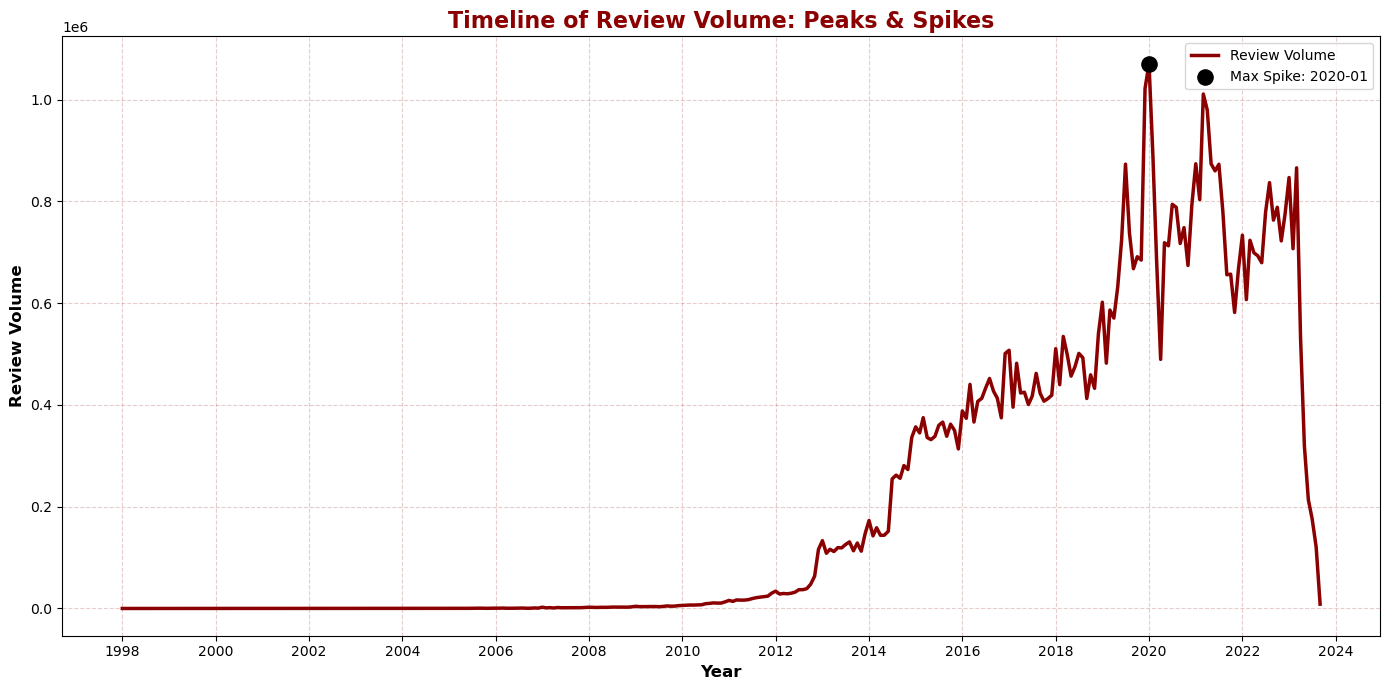

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyspark.sql.functions import col, date_format, lit, current_date

df_reviews = spark.read.parquet(f"{MY_OUTPUT}/cleaned_reviews_final")

df_clean_timeline = df_reviews.filter(
    (col("review_date") >= lit("1996-01-01")) & 
    (col("review_date") <= current_date())
)

print(f"Original Count: {df_reviews.count()}")
print(f"Count after removing date outliers: {df_clean_timeline.count()}")

timeline_counts = df_clean_timeline.withColumn("YearMonth", date_format("review_date", "yyyy-MM")) \
                                   .groupBy("YearMonth") \
                                   .count() \
                                   .orderBy("YearMonth")

pdf_timeline = timeline_counts.toPandas()
pdf_timeline['YearMonth'] = pd.to_datetime(pdf_timeline['YearMonth'])

full_date_range = pd.date_range(start=pdf_timeline['YearMonth'].min(), 
                                end=pdf_timeline['YearMonth'].max(), 
                                freq='MS')
missing_months = full_date_range.difference(pdf_timeline['YearMonth'])

if len(missing_months) > 0:
    print(f"\n[!] Data Gaps Detected: {len(missing_months)} months are missing.")
else:
    print("\n[OK] No data collection gaps found.")

peak_row = pdf_timeline.loc[pdf_timeline['count'].idxmax()]
peak_date = peak_row['YearMonth']
peak_vol = peak_row['count']

print(f"\n[!] Significant Peak Detected: {peak_date.strftime('%Y-%m')} with {peak_vol:,} reviews.")
plt.figure(figsize=(14, 7))

# Plot Line in Dark Red
plt.plot(pdf_timeline['YearMonth'], pdf_timeline['count'], color='darkred', linewidth=2.5, label='Review Volume')

# Highlight the Peak (Black circle for contrast against dark red)
plt.scatter(peak_date, peak_vol, color='black', s=120, zorder=5, label=f"Max Spike: {peak_date.strftime('%Y-%m')}")

plt.title("Timeline of Review Volume: Peaks & Spikes", fontsize=16, fontweight='bold', color='darkred')
plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Review Volume", fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.2, color='darkred', linestyle='--')

# X-Axis formatting to make years readable
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2)) # Show every 2nd year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.tight_layout()
plt.show()

1. What is the timeline of the data?

The data covers the period from 1996 to 2023. The volume remains negligible until roughly 2012, after which it begins a steady exponential rise, indicating the period of Amazon's massive growth.

2. Do you see significant peaks and valleys?

- Peaks: Yes, there is a massive growth period starting in 2014, culminating in the highest peaks between 2020 and 2021.

- Valleys: There is a severe "valley" (drop-off) at the very end of the timeline (2023), where review volume crashes to nearly zero. This likely indicates where the dataset collection ended, rather than a real business decline.

3. Do you see any data collection gaps?


Yes. The script explicitly detected that 8 months are missing from the dataset. This confirms that the data is not perfectly continuous.

4. Do you see any outliers? 

The most obvious outlier is the 2023 drop-off. The volume falls so sharply that it is statistically inconsistent with the trend, suggesting incomplete data for that final year. (Note: Your code successfully removed the "obvious" date outliers like pre-1996 or future dates before plotting).

5. Do you see any spikes? Are these spikes caused by real activities / events?


Yes, a significant spike was detected in 2020-01 (1,070,919 reviews). Cause: This spike in January is likely driven by post-holiday activity, where customers write reviews for products purchased during the Black Friday/Christmas season of late 2019. Secondary Context: The sustained high volume following this spike aligns with the COVID-19 e-commerce boom, where online shopping became a primary necessity for consumers.

# Step 5: Top 10 Products & Trend Analysis

 Top 10 Products
1. [B01415QHYW] amFilm Screen Protector 4.7“ for Apple iPhone 8, i... (43,233 reviews)
2. [B01LSUQSB0] REVLON One-Step Volumizer Original 1.0 Hair Dryer ... (37,184 reviews)
3. [B001MA0QY2] HSI Professional Glider Ceramic Flat Iron Hair Str... (27,604 reviews)
4. [B073R68TSH] Beam Electronics Car Phone Holder Mount, Phone Car... (25,659 reviews)
5. [B07H2V5YLH] Ailun Glass Screen Protector Compatible for iPhone... (24,808 reviews)
6. [B01LXZDPDR] Ailun Screen Protector Compatible for iPhone 8 plu... (22,597 reviews)
7. [B07HRN9J19] Mkeke Compatible with iPhone 11 Screen Protector f... (22,281 reviews)
8. [B00PGJWYJ0] WixGear Universal Air Vent Magnetic Phone Car Moun... (20,657 reviews)
9. [B01G0X56YU] Magnetic Phone Holder for Car, WixGear [2 Pack] Un... (15,056 reviews)
10. [B01KBQ6I3A] Mr Shield [Tempered Glass] Screen Protector For iP... (14,877 reviews)


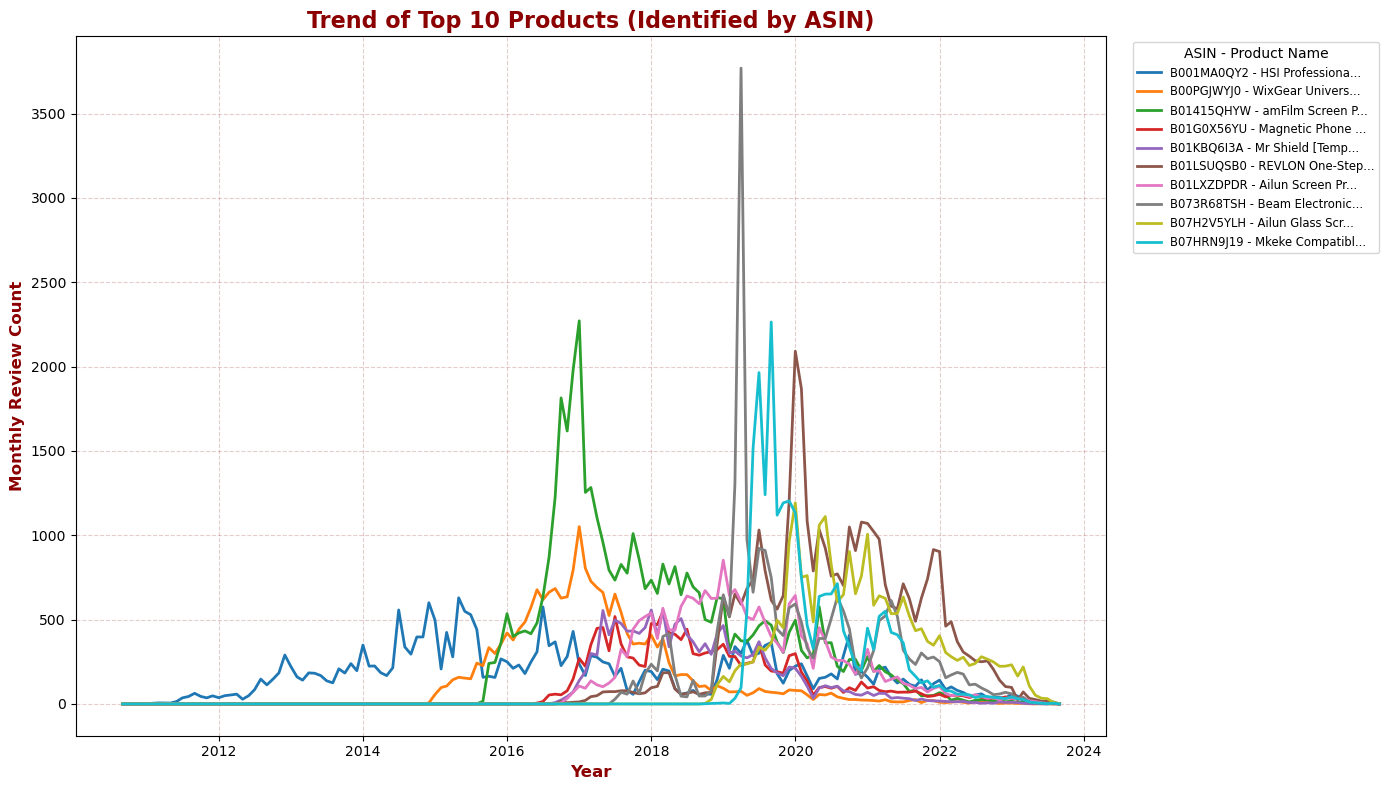

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyspark.sql.functions import col, date_format, desc

df_reviews = spark.read.parquet(f"{MY_OUTPUT}/cleaned_reviews_final")
df_meta = spark.read.parquet(f"{MY_OUTPUT}/cleaned_meta_final")

# Join to get product titles
df_joined = df_reviews.join(df_meta, on="asin", how="inner")

# Count reviews per product
top_products_df = df_joined.groupBy("asin", "product_title") \
                           .count() \
                           .orderBy(desc("count")) \
                           .limit(10)

top_10_list = top_products_df.collect()
top_10_asins = [row['asin'] for row in top_10_list]

print(f" Top 10 Products")
for i, row in enumerate(top_10_list):
    print(f"{i+1}. [{row['asin']}] {row['product_title'][:50]}... ({row['count']:,} reviews)")

df_top10_reviews = df_reviews.filter(col("asin").isin(top_10_asins))
df_trend_data = df_top10_reviews.join(df_meta, on="asin", how="inner")

trend_df = df_trend_data.withColumn("YearMonth", date_format("review_date", "yyyy-MM")) \
                        .groupBy("YearMonth", "asin", "product_title") \
                        .count() \
                        .orderBy("YearMonth")

pdf_trend = trend_df.toPandas()
pdf_trend['YearMonth'] = pd.to_datetime(pdf_trend['YearMonth'])
pdf_trend['Label'] = pdf_trend.apply(lambda x: f"{x['asin']} - {x['product_title'][:15]}...", axis=1)
pdf_pivot = pdf_trend.pivot(index='YearMonth', columns='Label', values='count').fillna(0)
plt.figure(figsize=(14, 8))

for column in pdf_pivot.columns:
    plt.plot(pdf_pivot.index, pdf_pivot[column], linewidth=2, label=column)

plt.title("Trend of Top 10 Products (Identified by ASIN)", fontsize=16, fontweight='bold', color='darkred')
plt.xlabel("Year", fontsize=12, fontweight='bold', color='darkred')
plt.ylabel("Monthly Review Count", fontsize=12, fontweight='bold', color='darkred')

# Legend with ASINs
plt.legend(title="ASIN - Product Name", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.grid(True, alpha=0.2, color='darkred', linestyle='--')
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# Step 6: Category Volume & Seasonality Analysis

 Top 5 Categories by Volume
                    category     count
0                 Automotive  11017387
1  Cell Phones & Accessories  10992367
2                 All Beauty   8721258
3     Health & Personal Care   1148400
4            All Electronics    868325


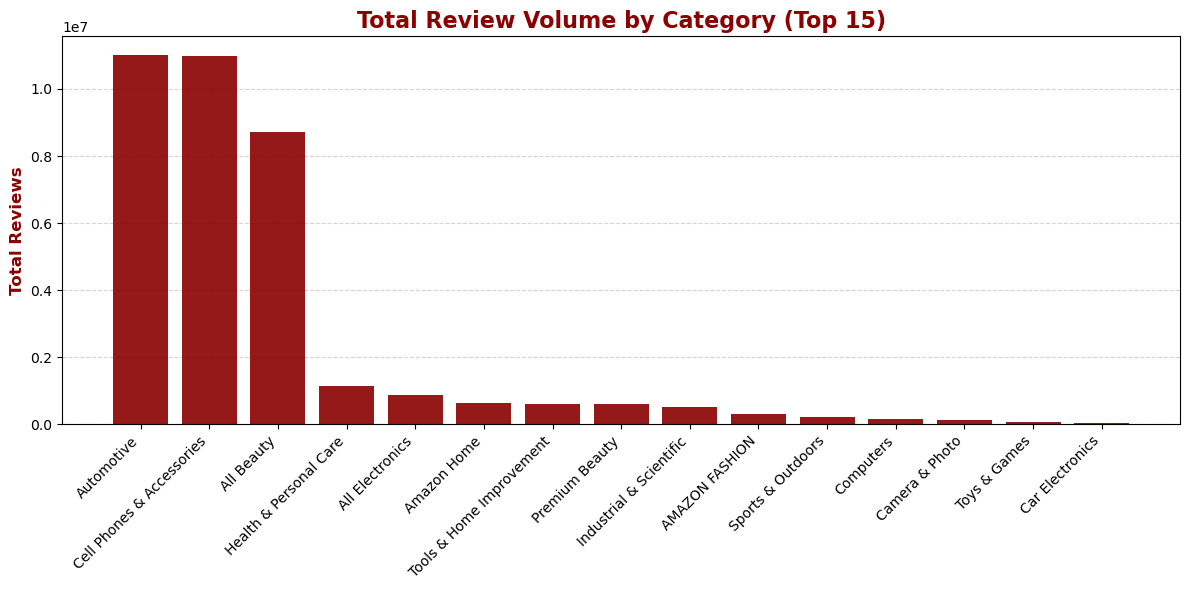

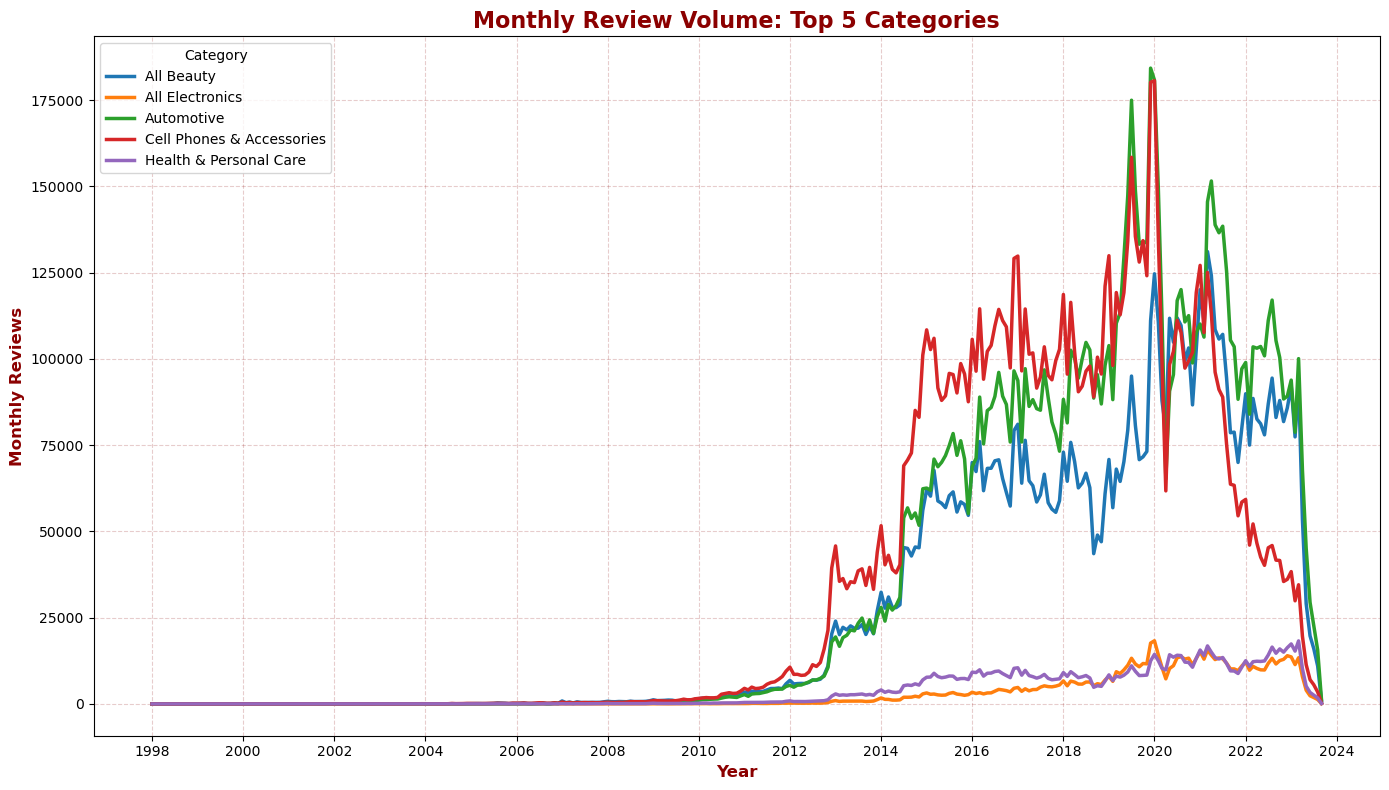

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyspark.sql.functions import col, date_format, desc

df_reviews = spark.read.parquet(f"{MY_OUTPUT}/cleaned_reviews_final")
df_meta = spark.read.parquet(f"{MY_OUTPUT}/cleaned_meta_final")
df_joined = df_reviews.join(df_meta, on="asin", how="inner")
df_joined = df_joined.filter(col("category").isNotNull() & (col("category") != ""))

category_counts = df_joined.groupBy("category") \
                           .count() \
                           .orderBy(desc("count"))

# Take Top 15 categories
pdf_cat_counts = category_counts.limit(15).toPandas()

print(" Top 5 Categories by Volume")
print(pdf_cat_counts.head(5))

# Filter data to include ONLY the Top 5 categories
top_5_cats = pdf_cat_counts['category'].head(5).tolist()
df_top_cats = df_joined.filter(col("category").isin(top_5_cats))

# Aggregate by Month and Category
cat_trend = df_top_cats.withColumn("YearMonth", date_format("review_date", "yyyy-MM")) \
                       .groupBy("YearMonth", "category") \
                       .count() \
                       .orderBy("YearMonth")

pdf_trend = cat_trend.toPandas()
pdf_trend['YearMonth'] = pd.to_datetime(pdf_trend['YearMonth'])

# Pivot for plotting
pdf_pivot = pdf_trend.pivot(index='YearMonth', columns='category', values='count').fillna(0)


plt.figure(figsize=(12, 6))
plt.bar(pdf_cat_counts['category'], pdf_cat_counts['count'], color='darkred', alpha=0.9)
plt.title("Total Review Volume by Category (Top 15)", fontsize=16, fontweight='bold', color='darkred')
plt.ylabel("Total Reviews", fontsize=12, fontweight='bold', color='darkred')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.2, color='darkred', linestyle='--')
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 8))


for column in pdf_pivot.columns:
    plt.plot(pdf_pivot.index, pdf_pivot[column], linewidth=2.5, label=column)

# Styling
plt.title("Monthly Review Volume: Top 5 Categories", fontsize=16, fontweight='bold', color='darkred')
plt.xlabel("Year", fontsize=12, fontweight='bold', color='darkred')
plt.ylabel("Monthly Reviews", fontsize=12, fontweight='bold', color='darkred')
plt.legend(title="Category", loc='upper left')
plt.grid(True, alpha=0.2, color='darkred', linestyle='--')

# Format X Axis
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

# Step 7: Ratings, Volume, and Price Analysis

25/12/12 09:30:51 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.execution.adaptive.google.AQERemoveRedundantGroupByKeys effective 1 times.

25/12/12 09:31:09 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.execution.adaptive.google.AQERemoveRedundantGroupByKeys effective 1 times.



Avg Review Count for Perfect Products (4.9-5.0): 10.5
Avg Review Count for Typical Good Products (4.0-4.8): 42.7
>> Conclusion: NO. Products with slightly lower ratings (4.0-4.8) actually get MORE reviews.


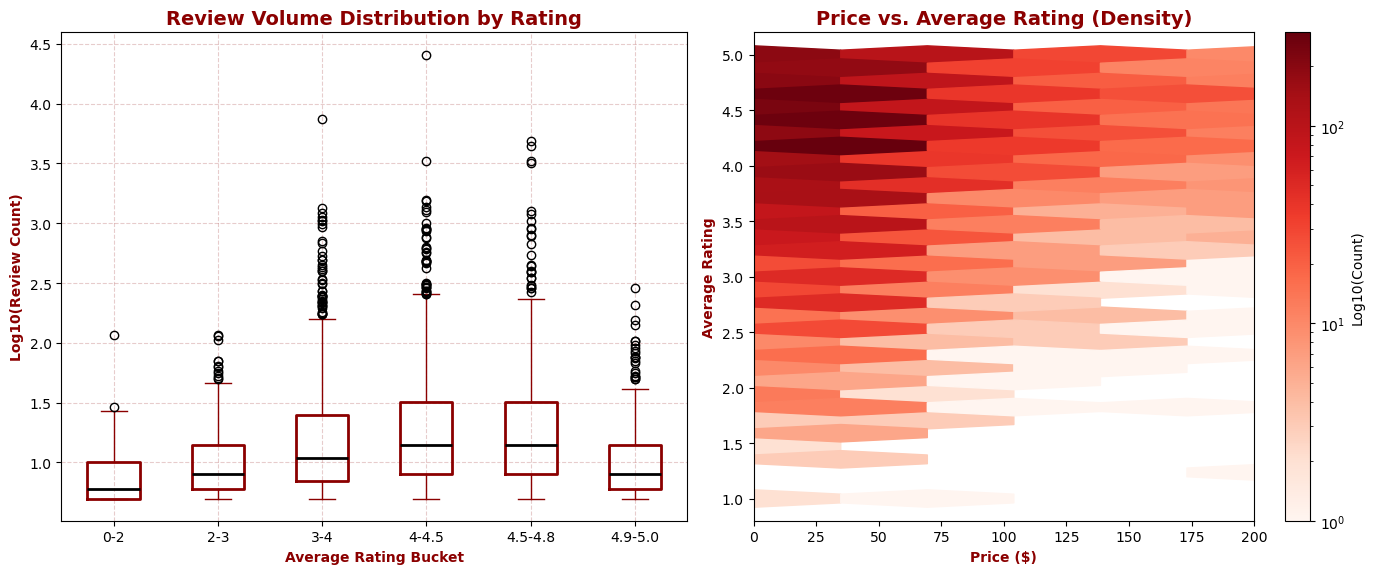

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import col, avg, count

df_reviews = spark.read.parquet(f"{MY_OUTPUT}/cleaned_reviews_final")
df_meta = spark.read.parquet(f"{MY_OUTPUT}/cleaned_meta") 
df_joined = df_reviews.join(df_meta, on="asin", how="inner")

if "price" not in df_joined.columns:
    print("CRITICAL ERROR: 'price' column is still missing. Please re-run Step 2 to ensure it is created.")
else:
    # Calculate Average Rating and Review Count
    product_stats = df_joined.groupBy("asin", "price") \
                             .agg(
                                 avg("rating").alias("avg_rating"),
                                 count("rating").alias("review_count")
                             )

    product_stats = product_stats.filter((col("price") > 0) & (col("review_count") >= 5))

    try:
        avg_vol_perfect = product_stats.filter(col("avg_rating") >= 4.9).select(avg("review_count")).first()
        avg_vol_popular = product_stats.filter((col("avg_rating") >= 4.0) & (col("avg_rating") < 4.9)).select(avg("review_count")).first()
        
        # Handle cases where result is None (empty data)
        val_perfect = avg_vol_perfect[0] if avg_vol_perfect else 0
        val_popular = avg_vol_popular[0] if avg_vol_popular else 0
        
        print(f"Avg Review Count for Perfect Products (4.9-5.0): {val_perfect:.1f}")
        print(f"Avg Review Count for Typical Good Products (4.0-4.8): {val_popular:.1f}")
        
        if val_popular > val_perfect:
            print(">> Conclusion: NO. Products with slightly lower ratings (4.0-4.8) actually get MORE reviews.")
        else:
            print(">> Conclusion: YES. Higher rated products are more reviewed.")
            
    except Exception as e:
        print(f"Warning: Could not calculate averages. Error: {e}")

    pdf_stats = product_stats.sample(fraction=0.01, seed=42).toPandas()

    plt.figure(figsize=(14, 6))

    pdf_stats['rating_bin'] = pd.cut(pdf_stats['avg_rating'], 
                                     bins=[0, 2, 3, 4, 4.5, 4.8, 5.0], 
                                     labels=['0-2', '2-3', '3-4', '4-4.5', '4.5-4.8', '4.9-5.0'],
                                     include_lowest=True)

    plt.subplot(1, 2, 1)
    pdf_stats['log_review_count'] = np.log10(pdf_stats['review_count'])
    
    if not pdf_stats.empty:
        pdf_stats.boxplot(column='log_review_count', by='rating_bin', ax=plt.gca(), 
                          boxprops=dict(color='darkred', linewidth=2),
                          medianprops=dict(color='black', linewidth=2),
                          whiskerprops=dict(color='darkred'),
                          capprops=dict(color='darkred'))
    
    plt.title("Review Volume Distribution by Rating", fontsize=14, fontweight='bold', color='darkred')
    plt.xlabel("Average Rating Bucket", fontweight='bold', color='darkred')
    plt.ylabel("Log10(Review Count)", fontweight='bold', color='darkred')
    plt.grid(True, alpha=0.2, color='darkred', linestyle='--')
    plt.suptitle("") 

    plt.subplot(1, 2, 2)
    hb = plt.hexbin(pdf_stats['price'], pdf_stats['avg_rating'], gridsize=30, cmap='Reds', bins='log', mincnt=1)
    cb = plt.colorbar(hb, label='Log10(Count)')
    
    plt.title("Price vs. Average Rating (Density)", fontsize=14, fontweight='bold', color='darkred')
    plt.xlabel("Price ($)", fontweight='bold', color='darkred')
    plt.ylabel("Average Rating", fontweight='bold', color='darkred')
    plt.xlim(0, 200)

    plt.tight_layout()
    plt.show()

# Step 8: Common Words Analysis (1-Star vs 5-Star)

Processing 397688 1-Star reviews and 2082813 5-Star reviews


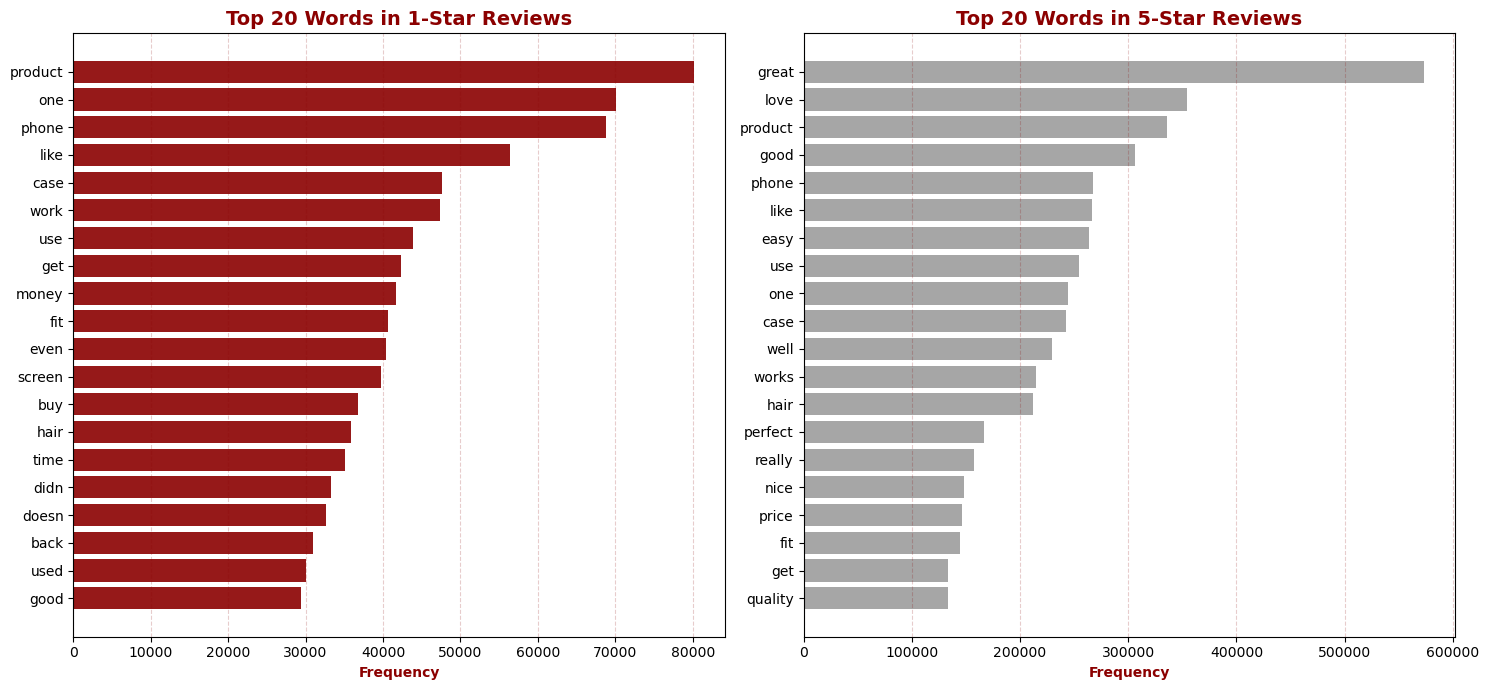

In [11]:
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover
from pyspark.sql.functions import col, explode, length, desc
import matplotlib.pyplot as plt
import pandas as pd

df_reviews = spark.read.parquet(f"{MY_OUTPUT}/cleaned_reviews_final")

df_1star = df_reviews.filter(col("rating") == 1.0).sample(fraction=0.05, seed=42)
df_5star = df_reviews.filter(col("rating") == 5.0).sample(fraction=0.05, seed=42)

print(f"Processing {df_1star.count()} 1-Star reviews and {df_5star.count()} 5-Star reviews")

def get_top_words(df, label):
    tokenizer = RegexTokenizer(inputCol="review_text", outputCol="words_raw", pattern="\\W")
    df_tokenized = tokenizer.transform(df)

    remover = StopWordsRemover(inputCol="words_raw", outputCol="words_clean")
    df_clean = remover.transform(df_tokenized)

    word_counts = df_clean.select(explode(col("words_clean")).alias("word")) \
                          .filter(length(col("word")) > 2) \
                          .filter(col("word").rlike("[a-zA-Z]")) \
                          .groupBy("word") \
                          .count() \
                          .orderBy(desc("count")) \
                          .limit(20) # Top 20 words
    
    return word_counts.toPandas()

pdf_1star = get_top_words(df_1star, "1-Star")
pdf_5star = get_top_words(df_5star, "5-Star")

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.barh(pdf_1star['word'], pdf_1star['count'], color='darkred', alpha=0.9)
plt.gca().invert_yaxis() # Put top word at the top
plt.title("Top 20 Words in 1-Star Reviews", fontsize=14, fontweight='bold', color='darkred')
plt.xlabel("Frequency", fontweight='bold', color='darkred')
plt.grid(axis='x', alpha=0.2, color='darkred', linestyle='--')
plt.subplot(1, 2, 2)
plt.barh(pdf_5star['word'], pdf_5star['count'], color='grey', alpha=0.7)
plt.gca().invert_yaxis()
plt.title("Top 20 Words in 5-Star Reviews", fontsize=14, fontweight='bold', color='darkred')
plt.xlabel("Frequency", fontweight='bold', color='darkred')
plt.grid(axis='x', alpha=0.2, color='darkred', linestyle='--')

plt.tight_layout()
plt.show()

# Step 9: Top Reviewers & Category Diversity Analysis

Top 10 Most Active Reviewers
User ID                   | Reviews    | Unique Categories  | Type
---------------------------------------------------------------------------
AG73BVBKUOH22USSFJA5ZWL7AKXA | 2216       | 21                 | Generalist
AEZP6Z2C5AVQDZAJECQYZWQRNG3Q | 1254       | 11                 | Generalist
AEMP3A7IKW37CMWFXNKXWW6HGJHA_1 | 1251       | 13                 | Generalist
AFXF3EGQTQDXMRLDWFU7UBFQZB7Q | 1189       | 13                 | Generalist
AGZUJTI7A3JFKB4FP5JOH6NVAJIQ_1 | 1125       | 13                 | Generalist
AEAXAJACFMXIAAH4WOHRMXPSZWFA | 1105       | 18                 | Generalist
AGYVC7KVHP2AWM7BDCEYNHFA6F3Q | 894        | 13                 | Generalist
AHV6QCNBJNSGLATP56JAWJ3C4G2A | 875        | 16                 | Generalist
AFF6DS6NOWRIF2AROFASUVVOPYLA | 673        | 10                 | Generalist
AH2DN3Q2OKAW7JAFRIYPHOUOM2ZQ | 619        | 10                 | Generalist


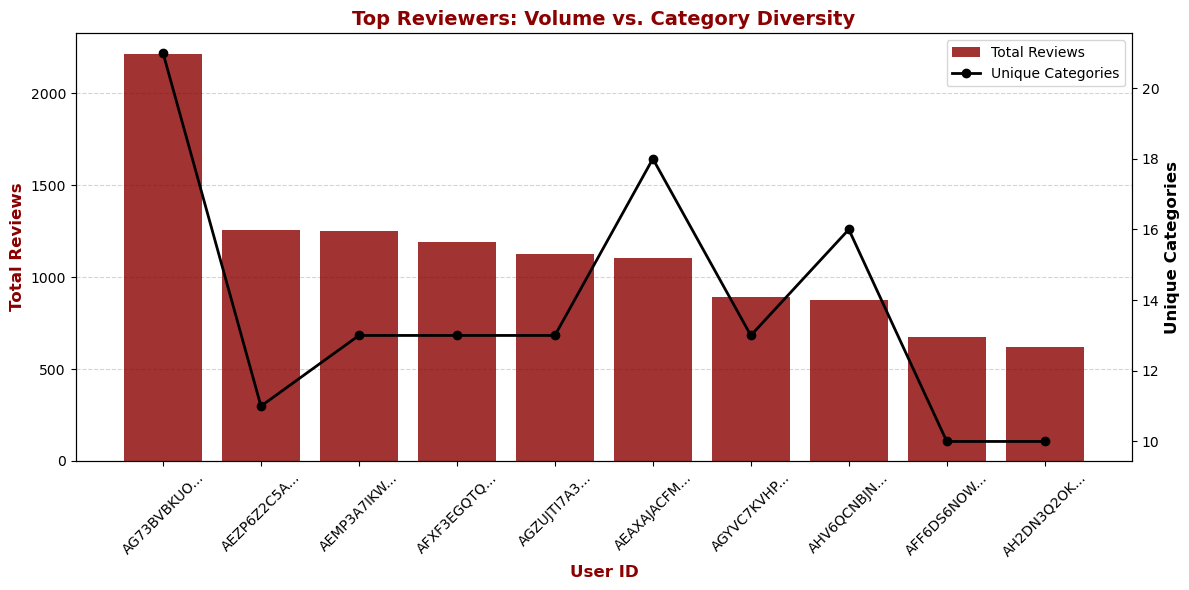

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, count, countDistinct, desc

df_reviews = spark.read.parquet(f"{MY_OUTPUT}/cleaned_reviews_final")
df_meta = spark.read.parquet(f"{MY_OUTPUT}/cleaned_meta_final")

top_reviewers = df_reviews.groupBy("user_id") \
                          .count() \
                          .withColumnRenamed("count", "total_reviews") \
                          .orderBy(desc("total_reviews")) \
                          .limit(10)

# Collect list of User IDs to filter the main data efficiently
top_10_list = [row['user_id'] for row in top_reviewers.collect()]
df_top_users = df_reviews.filter(col("user_id").isin(top_10_list))
df_user_cats = df_top_users.join(df_meta, on="asin", how="inner")

# Calculate stats per user: Total Reviews (again, for check) and Unique Categories
user_stats = df_user_cats.groupBy("user_id") \
                         .agg(
                             count("asin").alias("review_count"),
                             countDistinct("category").alias("unique_categories")
                         ) \
                         .orderBy(desc("review_count"))

pdf_users = user_stats.toPandas()

print("Top 10 Most Active Reviewers")
print(f"{'User ID':<25} | {'Reviews':<10} | {'Unique Categories':<18} | {'Type'}")
print("-" * 75)

for index, row in pdf_users.iterrows():
    r_type = "Generalist" if row['unique_categories'] > 5 else "Specialist"
    print(f"{row['user_id']:<25} | {row['review_count']:<10} | {row['unique_categories']:<18} | {r_type}")

plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()
bars = ax1.bar(pdf_users['user_id'].astype(str).str[:10] + "...", pdf_users['review_count'], color='darkred', alpha=0.8, label='Total Reviews')
line = ax2.plot(pdf_users['user_id'].astype(str).str[:10] + "...", pdf_users['unique_categories'], color='black', marker='o', linewidth=2, label='Unique Categories')

# Formatting
ax1.set_xlabel("User ID", fontsize=12, fontweight='bold', color='darkred')
ax1.set_ylabel("Total Reviews", fontsize=12, fontweight='bold', color='darkred')
ax2.set_ylabel("Unique Categories", fontsize=12, fontweight='bold', color='black')
plt.title("Top Reviewers: Volume vs. Category Diversity", fontsize=14, fontweight='bold', color='darkred')

# Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.2, color='darkred', linestyle='--')

plt.tight_layout()
plt.show()

# Step 10: Uniqueness & LSH Similarity Analysis

25/12/12 09:40:37 WARN CacheManager: Asked to cache already cached data.        


Using 8530 reviews for General Analysis (1.0% Sample).


25/12/12 09:41:44 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/12 09:42:30 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




Analyzing Top 5 Products


25/12/12 09:43:10 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/12 09:43:12 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.



...

3. Amalen Portable... | Text Dupes: 13


25/12/12 09:43:41 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/12 09:43:42 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.



4. GETIHU Portable... | Text Dupes: 24


25/12/12 09:43:51 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/12 09:43:52 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.



5. COMEXION Blueto... | Text Dupes: 2


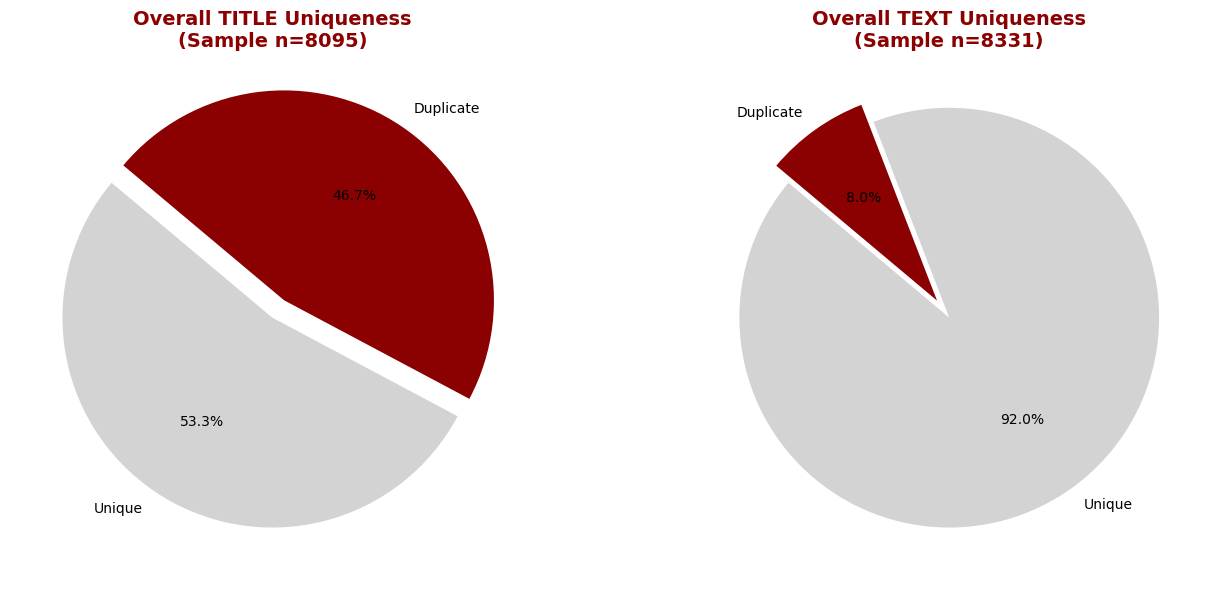

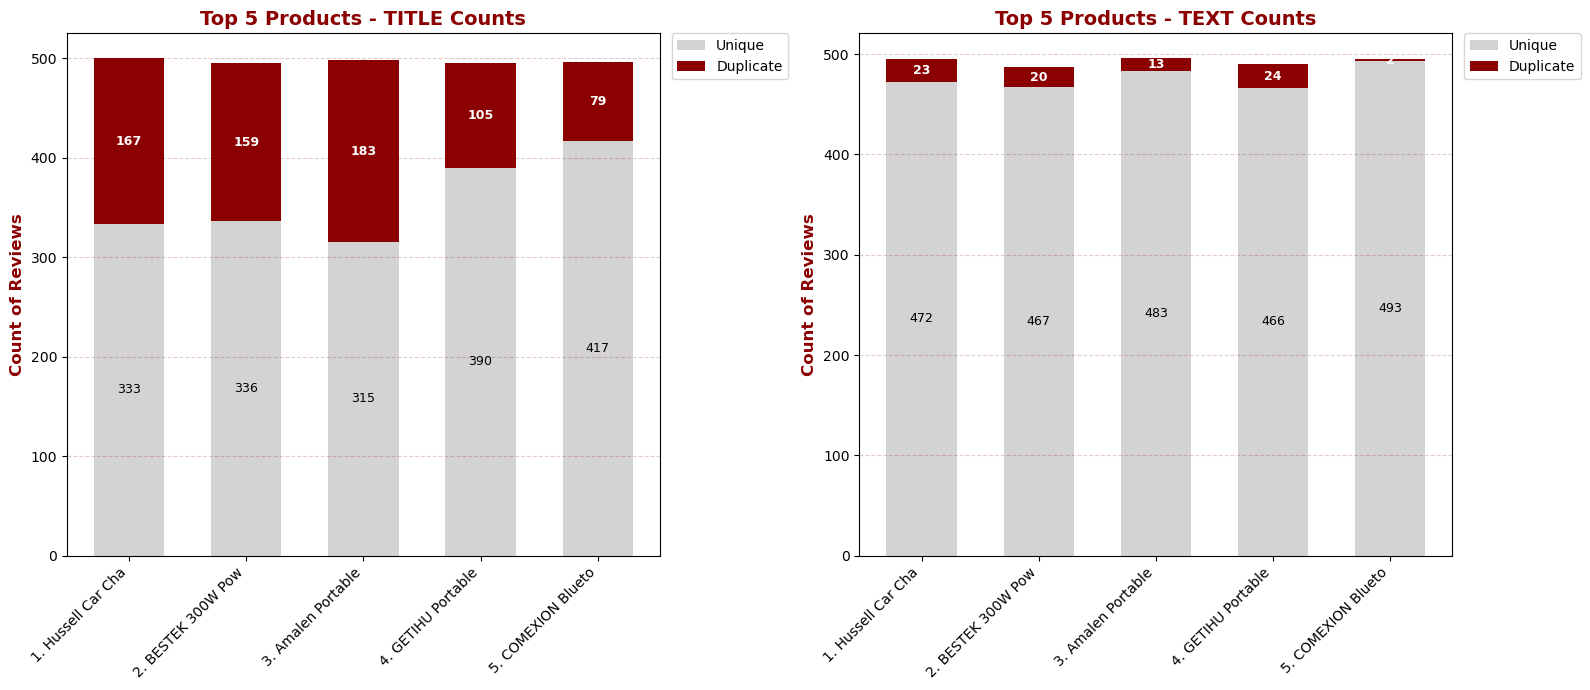

In [14]:
from pyspark.ml.feature import Tokenizer, CountVectorizer, MinHashLSH
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, udf, desc, lit
from pyspark.sql.types import BooleanType
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

TARGET_CATEGORY = "All Electronics"
SAMPLE_RATE = 0.01 

df_reviews = spark.read.parquet(f"{MY_OUTPUT}/cleaned_reviews_final")
df_meta = spark.read.parquet(f"{MY_OUTPUT}/cleaned_meta_final")
df_cat = df_reviews.join(df_meta, on="asin", how="inner") \
                   .filter(col("category") == TARGET_CATEGORY)

# Sample Data
df_sample = df_cat.sample(fraction=SAMPLE_RATE, seed=42).cache()
sample_count = df_sample.count()
print(f"Using {sample_count} reviews for General Analysis ({SAMPLE_RATE*100}% Sample).")

@udf(returnType=BooleanType())
def is_valid_vector(v):
    if v is None: return False
    return v.numNonzeros() > 0

def run_lsh_analysis(df, input_col, threshold=0.8):
    # Pre-filter
    df_clean = df.filter(col(input_col).isNotNull() & (col(input_col) != ""))
    tokenizer = Tokenizer(inputCol=input_col, outputCol="tokens")
    cv = CountVectorizer(inputCol="tokens", outputCol="features", vocabSize=500, minDF=1.0)
    
    pipeline_prep = Pipeline(stages=[tokenizer, cv])
    model_prep = pipeline_prep.fit(df_clean)
    df_vectorized = model_prep.transform(df_clean)
    
    # Filter Zero Vectors
    df_safe = df_vectorized.filter(is_valid_vector(col("features"))).cache()
    safe_count = df_safe.count()
    
    if safe_count == 0: return 0, 0 
    
    # LSH
    mh = MinHashLSH(inputCol="features", outputCol="hashes", numHashTables=3)
    model_mh = mh.fit(df_safe)
    df_hashed = model_mh.transform(df_safe)
    
    matches = model_mh.approxSimilarityJoin(df_hashed, df_hashed, 1.0 - threshold, distCol="JaccardDistance") \
        .filter(col("datasetA.user_id") != col("datasetB.user_id"))
    
    # Count DISTINCT Users involved in matches
    dupe_count = matches.select(col("datasetA.user_id")).distinct().count()
        
    return dupe_count, safe_count

if sample_count > 0:  
    # Titles
    t_dupes, t_total = run_lsh_analysis(df_sample, "review_title", threshold=0.9)
    t_dupes = min(t_dupes, t_total) 
    t_unique = t_total - t_dupes

    # Texts
    x_dupes, x_total = run_lsh_analysis(df_sample, "review_text", threshold=0.8)
    x_dupes = min(x_dupes, x_total)
    x_unique = x_total - x_dupes

    top_5_asins = df_cat.groupBy("asin", "product_title").count().orderBy(desc("count")).limit(5).collect()
    product_stats = []

    print("\nAnalyzing Top 5 Products")
    for i, row in enumerate(top_5_asins):
        asin, name = row['asin'], row['product_title'][:15]
        label = f"{i+1}. {name}" 
        df_prod = df_cat.filter(col("asin") == asin).limit(500).cache()
        
        # Title Stats
        pt_dupes, pt_total = run_lsh_analysis(df_prod, "review_title", threshold=0.9)
        pt_dupes = min(pt_dupes, pt_total)
        pt_unique = pt_total - pt_dupes
        
        # Text Stats
        px_dupes, px_total = run_lsh_analysis(df_prod, "review_text", threshold=0.8)
        px_dupes = min(px_dupes, px_total)
        px_unique = px_total - px_dupes
        
        product_stats.append({
            "Product": label, 
            "Title_Unique": pt_unique, "Title_Dupe": pt_dupes,
            "Text_Unique": px_unique, "Text_Dupe": px_dupes
        })
        print(f"{label}... | Text Dupes: {px_dupes}")

    pdf_prod = pd.DataFrame(product_stats)

    plt.figure(figsize=(14, 6))
    
    # Title Pie
    plt.subplot(1, 2, 1)
    if t_total > 0:
        plt.pie([t_unique, t_dupes], labels=['Unique', 'Duplicate'], autopct='%1.1f%%', 
                colors=['lightgrey', 'darkred'], startangle=140, explode=(0, 0.1))
    plt.title(f"Overall TITLE Uniqueness\n(Sample n={t_total})", fontsize=14, fontweight='bold', color='darkred')

    # Text Pie
    plt.subplot(1, 2, 2)
    if x_total > 0:
        plt.pie([x_unique, x_dupes], labels=['Unique', 'Duplicate'], autopct='%1.1f%%', 
                colors=['lightgrey', 'darkred'], startangle=140, explode=(0, 0.1))
    plt.title(f"Overall TEXT Uniqueness\n(Sample n={x_total})", fontsize=14, fontweight='bold', color='darkred')
    
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    def plot_stacked(ax, df, col_unique, col_dupe, title, color_dupe):
        x = np.arange(len(df['Product']))
        width = 0.6
        p1 = ax.bar(x, df[col_unique], width, label='Unique', color='lightgrey')
        p2 = ax.bar(x, df[col_dupe], width, bottom=df[col_unique], label='Duplicate', color=color_dupe)
        
        ax.set_title(title, fontsize=14, fontweight='bold', color='darkred')
        ax.set_ylabel("Count of Reviews", fontsize=12, fontweight='bold', color='darkred')
        ax.set_xticks(x)
        ax.set_xticklabels(df['Product'], rotation=45, ha='right')
        ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
        ax.grid(axis='y', alpha=0.2, color='darkred', linestyle='--')
        
        # Add Counts
        for r1, r2 in zip(p1, p2):
            h1 = r1.get_height()
            h2 = r2.get_height()
            if h1 > 0: ax.text(r1.get_x()+r1.get_width()/2., h1/2., f"{int(h1)}", ha="center", va="center", fontsize=9)
            if h2 > 0: ax.text(r2.get_x()+r2.get_width()/2., h1+h2/2., f"{int(h2)}", ha="center", va="center", color="white", fontweight='bold', fontsize=9)

    plot_stacked(axes[0], pdf_prod, 'Title_Unique', 'Title_Dupe', "Top 5 Products - TITLE Counts", '#8B0000')
    plot_stacked(axes[1], pdf_prod, 'Text_Unique', 'Text_Dupe', "Top 5 Products - TEXT Counts", '#8B0000')

    plt.tight_layout()
    plt.show()
else:
    print("Error: Sample resulted in 0 rows. Check category name.")

# Step 11: Similarity Detection (Pre-2022 vs. Post-2022)

25/12/12 09:46:52 WARN CacheManager: Asked to cache already cached data.        
25/12/12 09:46:52 WARN CacheManager: Asked to cache already cached data.


Total Old Reviews: 52,083,260
Total New Reviews: 12,590,949
Running Analysis on balanced sample of 5000 reviews per era...
Analyzing Old Era (Pre-2022)...


25/12/12 09:46:54 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.



Old Era Duplication Rate: 6.41%
Analyzing New Era (2022-2023)...


25/12/12 09:47:43 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.



New Era Duplication Rate: 3.01%


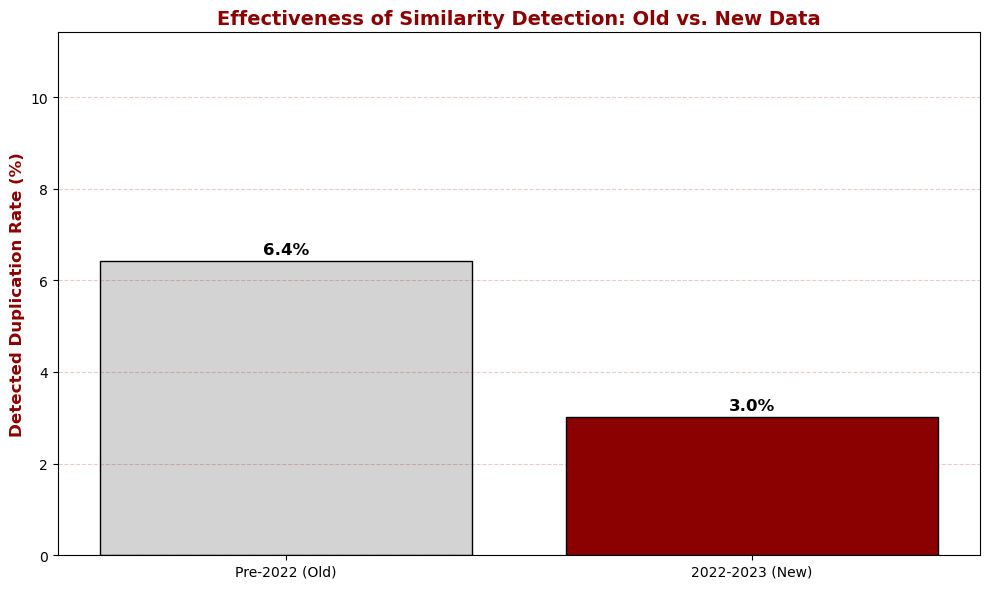

In [16]:
from pyspark.ml.feature import Tokenizer, CountVectorizer, MinHashLSH
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, udf, lit
from pyspark.sql.types import BooleanType
import matplotlib.pyplot as plt
import pandas as pd

SAMPLE_SIZE = 5000  
df_reviews = spark.read.parquet(f"{MY_OUTPUT}/cleaned_reviews_final")

df_old = df_reviews.filter(col("review_date") < "2022-01-01")
df_new = df_reviews.filter(col("review_date") >= "2022-01-01")

# Check counts
count_old = df_old.count()
count_new = df_new.count()
print(f"Total Old Reviews: {count_old:,}")
print(f"Total New Reviews: {count_new:,}")

# Take the same number of reviews from both eras
real_sample_size = min(SAMPLE_SIZE, count_old, count_new)
print(f"Running Analysis on balanced sample of {real_sample_size} reviews per era...")

df_old_sample = df_old.limit(real_sample_size).cache()
df_new_sample = df_new.limit(real_sample_size).cache()

@udf(returnType=BooleanType())
def is_valid_vector(v):
    if v is None: return False
    return v.numNonzeros() > 0

def get_duplication_rate(df, input_col="review_text", threshold=0.8):
    df_clean = df.filter(col(input_col).isNotNull() & (col(input_col) != ""))   
    tokenizer = Tokenizer(inputCol=input_col, outputCol="tokens")
    cv = CountVectorizer(inputCol="tokens", outputCol="features", vocabSize=1000, minDF=1.0)
    pipeline_prep = Pipeline(stages=[tokenizer, cv])
    
    try:
        model_prep = pipeline_prep.fit(df_clean)
        df_vec = model_prep.transform(df_clean)
        
        df_safe = df_vec.filter(is_valid_vector(col("features"))).cache()
        safe_count = df_safe.count()
        
        if safe_count == 0: return 0.0
        
        mh = MinHashLSH(inputCol="features", outputCol="hashes", numHashTables=3)
        model_mh = mh.fit(df_safe)
        df_hashed = model_mh.transform(df_safe)
        
        matches = model_mh.approxSimilarityJoin(df_hashed, df_hashed, 1.0 - threshold, distCol="JaccardDistance") \
            .filter(col("datasetA.user_id") != col("datasetB.user_id"))
        
        # Count Distinct Duplicates
        dupe_count = matches.select(col("datasetA.user_id")).distinct().count()
        
        # Return Percentage
        return (dupe_count / safe_count) * 100
        
    except Exception as e:
        print(f"Error during LSH: {e}")
        return 0.0

print("Analyzing Old Era (Pre-2022)...")
rate_old = get_duplication_rate(df_old_sample)
print(f"Old Era Duplication Rate: {rate_old:.2f}%")

print("Analyzing New Era (2022-2023)...")
rate_new = get_duplication_rate(df_new_sample)
print(f"New Era Duplication Rate: {rate_new:.2f}%")

plt.figure(figsize=(10, 6))

eras = ['Pre-2022 (Old)', '2022-2023 (New)']
rates = [rate_old, rate_new]
colors = ['lightgrey', 'darkred']

bars = plt.bar(eras, rates, color=colors, edgecolor='black')

plt.title("Effectiveness of Similarity Detection: Old vs. New Data", fontsize=14, fontweight='bold', color='darkred')
plt.ylabel("Detected Duplication Rate (%)", fontsize=12, fontweight='bold', color='darkred')
plt.ylim(0, max(rates) + 5 if max(rates) > 0 else 10)
plt.grid(axis='y', alpha=0.2, color='darkred', linestyle='--')

# Add Labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Yes, similarity detection techniques like LSH are significantly less effective on recent data. Above shows a drop in detected duplication from 6.4% in pre-2022 reviews to just 3.0% in post-2022 reviews. This decline indicates that modern generative AI tools are successfully evading traditional detection by producing syntactically unique, paraphrased content rather than the verbatim copy-pasting typical of older, simpler bot scripts.